In [3]:
import nltk
import pandas as pd 
df = pd.read_csv('../data/DisneylandReviews.csv', encoding='latin-1')

In [4]:
df.shape

(42656, 6)

In [5]:
df.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42656 entries, 0 to 42655
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Review_ID          42656 non-null  int64 
 1   Rating             42656 non-null  int64 
 2   Year_Month         42656 non-null  object
 3   Reviewer_Location  42656 non-null  object
 4   Review_Text        42656 non-null  object
 5   Branch             42656 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.0+ MB


In [7]:
df.describe()

,Review_ID,Rating
count,4.265600e+04,42656.000000
mean,3.188553e+08,4.217695
std,1.657092e+08,1.063371
min,1.398724e+06,1.000000
25%,1.743274e+08,4.000000
50%,2.907583e+08,5.000000
75%,4.489579e+08,5.000000
max,6.708014e+08,5.000000


In [8]:
df['Rating'].value_counts()

Rating
5    23146
4    10775
3     5109
2     2127
1     1499
Name: count, dtype: int64

In [9]:
df['Branch'].value_counts()

Branch
Disneyland_California    19406
Disneyland_Paris         13630
Disneyland_HongKong       9620
Name: count, dtype: int64

In [10]:
df.isnull().sum()

Review_ID            0
Rating               0
Year_Month           0
Reviewer_Location    0
Review_Text          0
Branch               0
dtype: int64

In [11]:
df['Rating'].value_counts().sort_index()

Rating
1     1499
2     2127
3     5109
4    10775
5    23146
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(12)

In [13]:
df['Review_Text'].head(10)

0    If you've ever been to Disneyland anywhere you...
1    Its been a while since d last time we visit HK...
2    Thanks God it wasn   t too hot or too humid wh...
3    HK Disneyland is a great compact park. Unfortu...
4    the location is not in the city, took around 1...
5    Have been to Disney World, Disneyland Anaheim ...
6    Great place! Your day will go by and you won't...
7    Think of it as an intro to Disney magic for th...
8    Feel so let down with this place,the Disneylan...
9    I can go on talking about Disneyland. Whatever...
Name: Review_Text, dtype: object

In [14]:
df = df.drop_duplicates() #suppression des doublons 

In [15]:
df.shape

(42644, 6)

In [16]:
df['review_length'] = df['Review_Text'].apply(len)
df['review_length'].describe()

count    42644.000000
mean       696.946487
std        831.468266
min         18.000000
25%        239.000000
50%        435.000000
75%        838.000000
max      20756.000000
Name: review_length, dtype: float64

##### Le dataset contient 42 656 avis sur 3 parcs Disneyland. Aucune valeur manquante, 12 doublons supprimés. La distribution des notes est déséquilibrée avec 54% de notes 5/5. Les avis sont relativement longs, ce qui est favorable pour l'analyse NLP.

In [17]:
df[df['review_length'] == df['review_length'].max()]['Review_Text'].values[0]

"After having visited Disneyland Paris at least 20 times in the past year, I have come to realize that the secret to having a good time there is as much about knowing what NOT TO DO as knowing what to do. So, one of the first things I tell people not to do is over schedule themselves and their families. One must reign in one's expectations. You cannot do 20 rides in one day. It is unlikely you will be able to do 10. Even if the park is completely empty, it is HUGE and it takes quite a bit of time to walk from point A to point B, particularly on the Magic Kingdom side. Most people really don't take this into consideration. For example, if you get a Fast Pass for the Buzz Lightyear ride and then think you will just nip on over to the Pirates of the Caribbean while you wait, you may be in for a nasty surprise. These things are quite a distance from each other, and if P.O.C has any line at all, you might not make it. Personally, I consider it a really good day if we can go on 4 rides and s

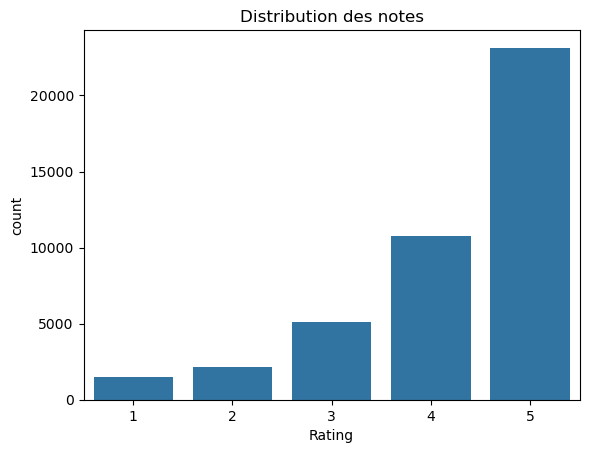

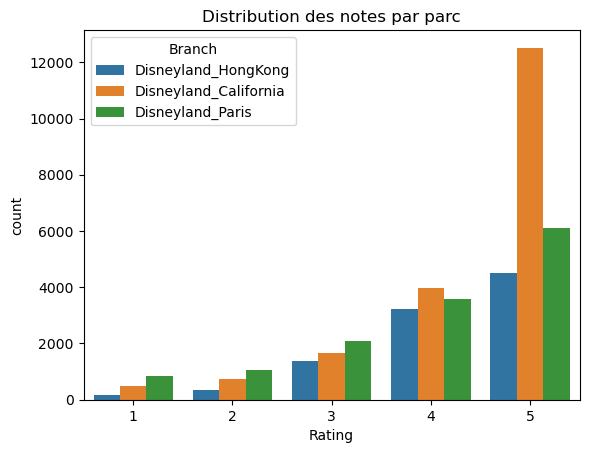

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution des notes
sns.countplot(x='Rating', data=df)
plt.title('Distribution des notes')
plt.show()

# 2. Distribution des notes par parc
sns.countplot(x='Rating', hue='Branch', data=df)
plt.title('Distribution des notes par parc')
plt.show()

##### Disneyland Paris affiche un taux d'avis négatifs (note 1-2) proportionnellement plus élevé que les parcs de Californie et Hong Kong. L'analyse de sentiment permettra d'identifier les motifs spécifiques d'insatisfaction

## Preprocessing NLP 

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Mettre en minuscules
    text = text.lower()
    # 2. Supprimer tout ce qui n'est pas une lettre
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Tokeniser (découper en mots)
    tokens = word_tokenize(text)
    # 4. Supprimer les stopwords + lemmatiser
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

In [22]:
sample = df['Review_Text'].iloc[0]
print("AVANT:", sample[:200])
print("APRÈS:", preprocess_text(sample[:200]))

AVANT: If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World 
APRÈS: ever disneyland anywhere find disneyland hong kong similar layout walk main street familiar feel one ride small world
